<a href="https://colab.research.google.com/github/chuy-zip/COMPUTER_VISION_LAB6/blob/main/TASK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 2
### Integrantes
* Sergio Orellana 221122
* Rodrigo Mansilla 22611
* Ricardo Chuy 221007

### Tabla Para Task 3

In [18]:


try:
    accuracy_resnet = exactitud * 100
    f1_resnet = f1_macro
    size_resnet = tamano_mb
    inf_resnet = tiempo_inferencia_promedio

    accuracy_inception = exactitud_inc * 100
    f1_inception = f1_macro_inc
    size_inception = tamano_mb_inc
    inf_inception = tiempo_inferencia_promedio_inc

    accuracy_mobilenet = exactitud_mob * 100
    f1_mobilenet = f1_macro_mob
    size_mobilenet = tamano_mb_mob
    inf_mobilenet = tiempo_inferencia_promedio_mob

except NameError:
    accuracy_resnet = 99.00
    f1_resnet = 0.9900
    size_resnet = 90.04
    inf_resnet = 6.54

    accuracy_inception = 96.83
    f1_inception = 0.9677
    size_inception = 93.28
    inf_inception = 11.68

    accuracy_mobilenet = 99.00
    f1_mobilenet = 0.9901
    size_mobilenet = 8.76
    inf_mobilenet = 5.37

tabla_metricas = pd.DataFrame({
    "Modelo": ["ResNet50", "InceptionV3", "MobileNetV2"],
    "Accuracy (%)": [accuracy_resnet, accuracy_inception, accuracy_mobilenet],
    "F1-Score (Macro)": [f1_resnet, f1_inception, f1_mobilenet],
    "Tamaño (MB)": [size_resnet, size_inception, size_mobilenet],
    "Tiempo de inferencia (ms)": [inf_resnet, inf_inception, inf_mobilenet]
})

tabla_metricas = tabla_metricas.round({
    "Accuracy (%)": 2,
    "F1-Score (Macro)": 4,
    "Tamaño (MB)": 2,
    "Tiempo de inferencia (ms)": 2
})

print("Tabla comparativa final de modelos")
display(tabla_metricas)

Tabla comparativa final de modelos


,Modelo,Accuracy (%),F1-Score (Macro),Tamaño (MB),Tiempo de inferencia (ms)
0,ResNet50,99.00,0.9901,90.04,7.12
1,InceptionV3,96.50,0.9645,93.28,31.78
2,MobileNetV2,99.17,0.9920,8.76,6.35


### Curvas de pérdida por época

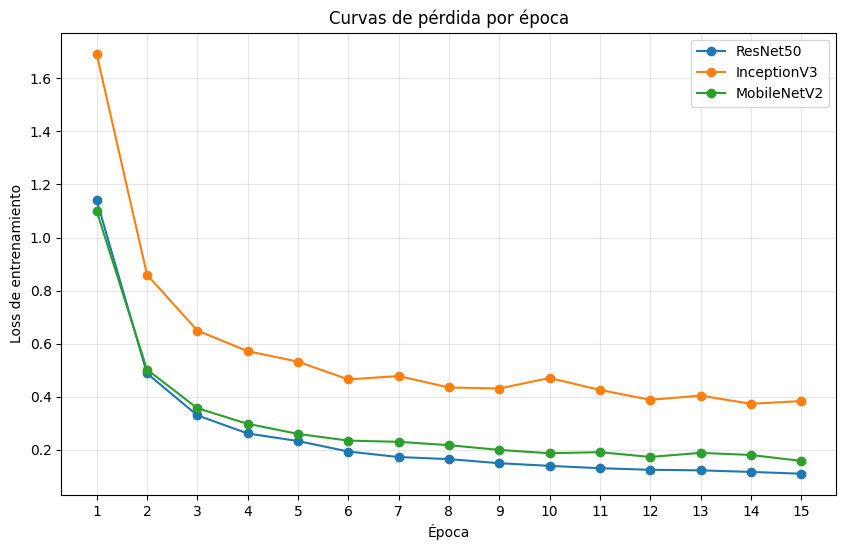

In [19]:
import matplotlib.pyplot as plt

epochs = list(range(1, 16))

loss_resnet = [
    1.1406, 0.4878, 0.3295, 0.2611, 0.2326,
    0.1930, 0.1722, 0.1644, 0.1489, 0.1389,
    0.1301, 0.1241, 0.1220, 0.1161, 0.1093
]

loss_inception = [
    1.6930, 0.8602, 0.6492, 0.5714, 0.5319,
    0.4649, 0.4776, 0.4345, 0.4306, 0.4702,
    0.4253, 0.3880, 0.4038, 0.3731, 0.3831
]

loss_mobilenet = [
    1.1003, 0.5022, 0.3564, 0.2976, 0.2595,
    0.2342, 0.2295, 0.2170, 0.1991, 0.1864,
    0.1906, 0.1725, 0.1880, 0.1800, 0.1576
]

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_resnet, marker="o", label="ResNet50")
plt.plot(epochs, loss_inception, marker="o", label="InceptionV3")
plt.plot(epochs, loss_mobilenet, marker="o", label="MobileNetV2")
plt.xlabel("Época")
plt.ylabel("Loss de entrenamiento")
plt.title("Curvas de pérdida por época")
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

###  Tamaño del modelo

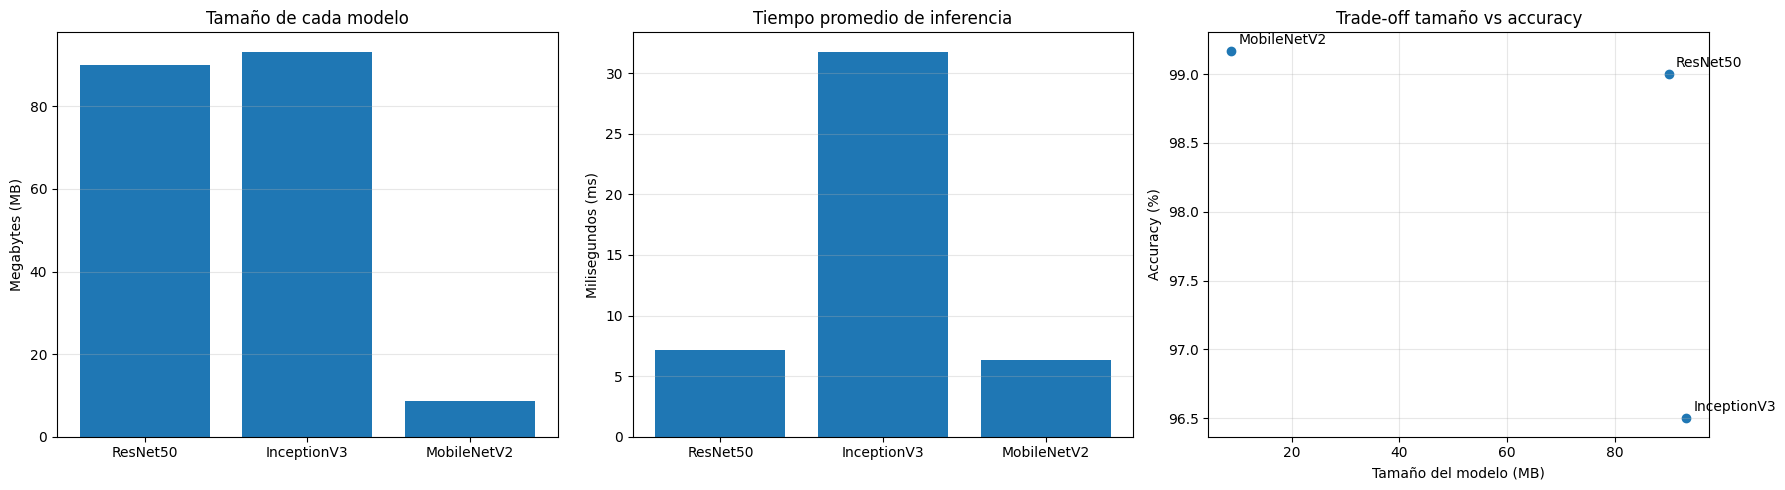

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 2: Tamaño del modelo
axes[0].bar(tabla_metricas["Modelo"], tabla_metricas["Tamaño (MB)"])
axes[0].set_ylabel("Megabytes (MB)")
axes[0].set_title("Tamaño de cada modelo")
axes[0].grid(True, axis="y", alpha=0.3)

# Gráfica 3: Tiempo de inferencia
axes[1].bar(tabla_metricas["Modelo"], tabla_metricas["Tiempo de inferencia (ms)"])
axes[1].set_ylabel("Milisegundos (ms)")
axes[1].set_title("Tiempo promedio de inferencia")
axes[1].grid(True, axis="y", alpha=0.3)

# Gráfica 4: Trade-off tamaño vs accuracy
axes[2].scatter(tabla_metricas["Tamaño (MB)"], tabla_metricas["Accuracy (%)"])

for _, row in tabla_metricas.iterrows():
    axes[2].annotate(
        row["Modelo"],
        (row["Tamaño (MB)"], row["Accuracy (%)"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

axes[2].set_xlabel("Tamaño del modelo (MB)")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Trade-off tamaño vs accuracy")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Se esperaba que la arquitectura MobileNet sacrificara precisión a consta de rendimiento. Sin embargo, de manera contraintuitriva y en este caso favorable para la misma, no se sacrifica nada de accuracy. Esto puede atribuirse a la redundancia que presentan arquitecturas másivas sobre tareas simples. En este caso MobileNet logró extraer de manera fuerte las representaciones para el set de datos. 

MobileNet transforma una convolución estandar de costo multiplicativo en sumas parciales. Al colocar casi el 95% de su cómputo en densas convoluciones de 1x1, el total de parámetros se reduce aproximadamente un 75% por capa, logrando un modelo liviano sin comprometer eficacia.

Con esto en cuenta, a modo de decisión se propone enviar a producción MobileNet, esto considerando la limitación de hardware que se presenta en campo. Al tomar esta arquitectura, se adapta al contexto, pesando solo 8.76mbs , lo cual favorece el empaquetado del modelo. Añadido a esto, el tiempo de inferencia permite grantizar que el uso sea rápido y no interrumpa el flujo de trabajo de los agentes. Como ultimo punto de selección, se comprobó que con un dataset estructurado puede llegar a desempeñar incluso mejor que arquitecturas grandes como ResNet/Inception. Enviar estas ultimas derrocharía 10 veces más almacenamiento y usaría más de recursos computacionales innecesariamente.